In [13]:
# ============================================================
# SurvivalPoleMDS クラス定義（Paper 1 静的分析・完全対応版）
# ============================================================
# 論文「Pole-augmented multidimensional scaling for descriptive
# descriptive survival-based visualization」の
# 静的分析を、そのまま追えるように整理した notebook 用クラス。
# 特定の応用分野に依存しない汎用実装である。
#
# この notebook での論文対応は次のとおり。
#   Table 1  : Distances from each covariate to the event pole (Monopolar)
#   Table 2  : Cox proportional hazards model
#   Figure 1 : Monopolar configuration
#   Table 3  : Bipolar configuration: distances to two poles + Delta
#   Figure 2 : Bipolar configuration
#   Table 4  : Monopolar with Cox residual added: distances
#   Table 5  : Bipolar with Cox residual added: distances to two poles + Delta
#   Figure 3 : Monopolar (left) and bipolar (right), Cox residual added
#
# 全体フロー:
#   1. __init__                       : データ受け取り, 3種類の残差計算
#   2. fit_all                        : 4モデル構成で sim/dist/coords を計算
#   3. build_monopolar_cmds_distance_table : 単極構成の 2D CMDS 座標距離表
#   4. build_cox_table                     : Cox 回帰の係数, ハザード比, p 値表
#   5. build_bipolar_cmds_distance_table   : 双極/Cox残差付き双極の 2D CMDS 座標距離・Delta 表
#   6. print_distance_table                : 距離テーブルを警告ブロック付きで画面表示
#   7. save_distance_table_to_csv          : 距離テーブルを警告ブロック付きで CSV 保存
#   8. print_diagnostics                   : 相関・距離・座標などの補助出力 (両方の距離を比較)
#   9. save_figures                        : 単極/双極/フルの図を PNG 保存
#
# 論文の表番号や CSV ファイル名はクラスでは持たず、ドライバ側で管理する.
#
# 重要: 距離の区別について
#   このクラスでは, 各 configuration ごとに 2 種類の距離行列を保持する.
#   - dist        : 入力距離行列 D = (1-r)^alpha (CMDS の入力)
#   - coord_dist  : 2 次元座標距離 D_hat = ||x_a - x_b|| (CMDS 出力後の射影距離)
#   論文の表 (Table 1, 3, 4, 5) に載せるのは coord_dist (2 次元座標距離) である.
#   入力距離 D は配置に依らず同じ値だが, 座標距離は configuration ごとに異なる.
#   両者は CMDS の 2 次元射影による情報損失のため, 一般に一致しない.
#   診断出力 (print_diagnostics) では両方を並べて表示し, 警告も付ける.
# ============================================================

# --- ライブラリの読み込み ---
# numpy: 数値計算の基本ライブラリ. 配列演算・線形代数の中核
import numpy as np

# pandas: 表形式データ（DataFrame）の操作
import pandas as pd

# matplotlib: 作図ライブラリ
import matplotlib
import matplotlib.pyplot as plt

# lifelines: 生存時間解析のライブラリ
#   NelsonAalenFitter : 累積ハザード Λ(t) の推定
#   KaplanMeierFitter : 生存関数 S(t) の推定
#   CoxPHFitter       : Cox 比例ハザード回帰
from lifelines import NelsonAalenFitter, KaplanMeierFitter, CoxPHFitter

# tabulate: 表を整形して標準出力に表示する
from tabulate import tabulate


class SurvivalPoleMDS:
    """極拡張 CMDS による生存分析データの静的可視化（汎用版）.

    任意の生存時間データセットに対して、イベント極と非イベント極を
    CMDS 空間に埋め込む可視化を行う. 残差計算、4 モデル構成の MDS、
    表と図の出力までを一括管理する.

    Paper 1 で提案された MDS による生存解析可視化の汎用実装.
    具体的なデータセット名やラベル名は __init__ 引数として
    外から与える.
    """

    # ============================================================
    # 距離取り違え防止のための警告文字列（クラス定数）
    # ============================================================
    # 距離行列・距離テーブルを返すメソッドが呼ばれるたびに,
    # 「これがどちらの距離か」を必ず print して人間に伝える.
    #
    # 入力距離 D = (1 - r_ab)^alpha : 配置に依らず, 相関値だけで決まる
    # 2D CMDS 座標距離 ||x_a - x_b|| : 2 次元配置上のユークリッド距離.
    #                                  configuration ごとに異なる.
    # 両者は CMDS の 2 次元射影による情報損失のため一般に一致しない.
    # この警告は print_diagnostics, build_*_cmds_distance_table,
    # get_*_distance_matrix 等から呼ばれる.

    _WARN_INPUT_DISTANCE = (
        "\n\n\n"
        "############################################################\n"
        "##                                                        ##\n"
        "##  WARNING about the values shown BELOW:                 ##\n"
        "##                                                        ##\n"
        "##  The values are the INPUT distance D given to CMDS,    ##\n"
        "##  D_ab = (1 - r_ab) ^ alpha.                            ##\n"
        "##  This is NOT the 2D coordinate distance                ##\n"
        "##  ||x_a - x_b|| in the CMDS configuration.              ##\n"
        "##                                                        ##\n"
        "##  The following values are the INPUT distance D.        ##\n"
        "##                                                        ##\n"
        "↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓"
    )

    _WARN_CMDS_COORD_DISTANCE = (
        "\n\n\n"
        "############################################################\n"
        "##                                                        ##\n"
        "##  WARNING about the values shown BELOW:                 ##\n"
        "##                                                        ##\n"
        "##  The values are 2D CMDS COORDINATE distances           ##\n"
        "##  ||x_a - x_b|| in the two-dimensional CMDS             ##\n"
        "##  configuration. They are NOT the input distance        ##\n"
        "##  D = (1 - r)^alpha. CMDS approximates D by 2D coords   ##\n"
        "##  with some loss; the two are not equal in general.     ##\n"
        "##                                                        ##\n"
        "##  The following values are 2D CMDS coordinate           ##\n"
        "##  distances ||x_a - x_b||.                              ##\n"
        "##                                                        ##\n"
        "↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓"
    )

    # ============================================================
    # 距離変換指数（論文 Method 3.3 — Distance transform）
    # ============================================================
    # 論文 Method 3.3 の距離変換式:
    #   共変量間      : d_ij = √(1-s_ij)       = (1-s)^0.5
    #   共変量–極間   : d_ij = (1-s_ij)^3     = (1-s)^3.0
    #   極間          : d_ij = (1-s_ij)^(1/4) = (1-s)^0.25
    #
    # これらの指数は、論文では表示の見せ方を調整する calibration choices
    # として位置づける。
    #
    # 注意:
    # 以前は COV_COV, COV_POLE, POLE_POLE をクラス定数として置いていたが、
    # 本版では __init__ の引数 cov_cov, cov_pole, pole_pole に既定値を直接書く。
    # そのため、通常は何も指定しなくても同じ数値で動き、必要な場合だけ
    # ドライバセルから指数を上書きできる。

    # ============================================================
    # 初期化
    # ============================================================
    def __init__(self, df, covariates, time_col, event_col, tau,
                 event_pole, nonevent_pole,
                 cox_resid_name='Cox residual',
                 dataset_name='Dataset',
                 display_names=None,
                 cov_cov=0.5,
                 cov_pole=3.0,
                 pole_pole=0.25):
        """初期化と 3 種類の残差計算.

        論文 Method 3.1 (Pole construction) と Method 3.2 (Cox residual)
        で定義される残差を全てここで計算して self に保持する.

        Parameters
        ----------
        df              : pandas.DataFrame, shape (N, ...)
            入力データ. 生存時間・イベント・共変量の列を持つ
        covariates      : list[str]
            共変量の列名リスト
        time_col        : str
            生存時間列の名前
        event_col       : str
            イベント列の名前
        tau             : int or float
            観測打ち切り時点（Pseudo-value 評価時点）
        event_pole      : str
            イベント極のラベル名（例: 'Event', 'Death', 'Failure', 'Relapse'）
        nonevent_pole   : str
            非イベント極のラベル名（例: 'Non-event', 'Survival', 'No-failure'）
        cox_resid_name  : str, default 'Cox residual'
            Cox 残差（共変量として追加）のラベル名
        dataset_name    : str, default 'Dataset'
            データセット名（記述統計・図タイトルの接頭辞）
        display_names   : dict[str, str] or None
            変数の内部名 → 表示名のマッピング. None なら恒等
        cov_cov         : float, default 0.5
            共変量–共変量ペアの距離変換指数
        cov_pole        : float, default 3.0
            共変量–極ペアの距離変換指数
        pole_pole       : float, default 0.25
            極–極ペアの距離変換指数
        """
        # 入力データをインスタンスに保持
        # self.df: pandas.DataFrame. 入力データの参照
        self.df = df
        # self.covariates: list[str]. 共変量の列名リスト
        self.covariates = covariates
        # self.time_col, self.event_col: str. 時間・イベント列名
        self.time_col = time_col
        self.event_col = event_col
        # self.tau: float. 観測打ち切り時点
        self.tau = tau
        # self.N: int. サンプルサイズ
        self.N = len(df)

        # --- 入力列とラベル名の簡易チェック ---
        # ここで止めることで、後段の相関計算や作図で原因不明のエラーになるのを防ぐ。
        required_columns = set(covariates + [time_col, event_col])
        missing_columns = sorted(required_columns - set(df.columns))
        if missing_columns:
            raise ValueError(f"Input df is missing required columns: {missing_columns}")

        item_names = list(covariates) + [event_pole, nonevent_pole, cox_resid_name]
        if len(item_names) != len(set(item_names)):
            raise ValueError(
                "covariates, event_pole, nonevent_pole, and cox_resid_name "
                "must be mutually unique."
            )

        # ============================================================
        # 距離変換指数（論文 Method 3.3 — Distance transform）
        # ============================================================
        # 引数で値を指定しない場合は、__init__ の既定値
        # cov_cov=0.5, cov_pole=3.0, pole_pole=0.25 が使われる。
        # 呼び出し時に指定すれば、その分析だけ指数を上書きできる。

        # 共変量–共変量ペアの距離変換指数. 型: float, 既定値: 0.5
        self.COV_COV = float(cov_cov)

        # 共変量–極ペアの距離変換指数. 型: float, 既定値: 3.0
        self.COV_POLE = float(cov_pole)

        # 極–極ペアの距離変換指数. 型: float, 既定値: 0.25
        self.POLE_POLE = float(pole_pole)

        # --- ラベル名の保持（汎用化のため外から受け取る）---
        # self.event_pole: str. イベント極のラベル名
        self.event_pole = event_pole
        # self.nonevent_pole: str. 非イベント極のラベル名
        self.nonevent_pole = nonevent_pole
        # self.cox_resid_name: str. Cox 残差のラベル名
        self.cox_resid_name = cox_resid_name
        # self.dataset_name: str. データセット名（表示用）
        self.dataset_name = dataset_name
        # self.POLE_NAMES: set[str]. 「極」として扱うラベル名の集合
        # `label in self.POLE_NAMES` の判定が O(1) で速いため set を使う
        self.POLE_NAMES = {event_pole, nonevent_pole}

        # self.display_names: dict[str, str]. 表示名マッピング
        # None のときは空 dict. dict.get(key, key) で fallback する運用
        if display_names is None:
            self.display_names = {}
        else:
            self.display_names = display_names

        # --- 残差計算（論文 Method 3.1, 3.2） ---
        # self.null_mart: numpy.ndarray, shape (N,). イベント極用残差
        self.null_mart = self.compute_null_martingale(
            df[time_col], df[event_col])

        # self.pseudo: numpy.ndarray, shape (N,). 非イベント極用 LOO pseudo-value
        # N 回の KM フィットを行うため数秒かかる
        self.pseudo = self.compute_pseudo_survival_loo(
            df[time_col].values, df[event_col].values, tau)

        # self.cox_mart: numpy.ndarray, shape (N,). Cox 残差（共変量扱い）
        # self.cph: lifelines.CoxPHFitter. フィット済みモデル
        self.cox_mart, self.cph = self.compute_cox_martingale(
            df, covariates, time_col, event_col)

        # --- MDS 用データフレーム ---
        # self.dm: pandas.DataFrame.
        # 共変量 + イベント極 + 非イベント極 + Cox 残差 を結合したデータ
        # .copy() で元の df を変更しないようにする（参照 vs コピー）
        self.dm = df[covariates].copy()
        self.dm[self.event_pole]     = self.null_mart
        self.dm[self.nonevent_pole]  = self.pseudo
        self.dm[self.cox_resid_name] = self.cox_mart

        # self.configs: dict. fit_all() で埋める. 4モデルの結果を格納
        self.configs = {}

    # ============================================================
    # 残差計算メソッド（論文 Method 3.1, 3.2）
    # ============================================================

    def compute_null_martingale(self, time, event):
        """Null マルチンゲール残差を計算（論文 Method 3.1 のイベント極用）.

        論文式: M_i = δ_i - Λ₀(T_i)
          δ_i     : イベント指示子
          Λ₀(T_i) : Nelson-Aalen 推定量による累積ハザード
        共変量を使わないのがポイント.

        Parameters
        ----------
        time  : pandas.Series または numpy.ndarray, shape (N,)
        event : pandas.Series または numpy.ndarray, shape (N,)

        Returns
        -------
        residual : numpy.ndarray, shape (N,)
        """
        # NelsonAalenFitter: lifelines が提供する累積ハザード推定器
        naf = NelsonAalenFitter()

        # fit で Λ₀(t) を推定
        naf.fit(time, event)

        # naf.predict(time) は各時刻 T_i における Λ₀(T_i) を pandas.Series で返す
        #
        # `.values` は pandas.Series を numpy.ndarray に変換する属性アクセスで、
        # 生の値だけを取り出すために使う. pandas のインデックスが邪魔に
        # なる場面でよく使うイディオム.
        cumhaz = naf.predict(time).values

        # M_i = δ_i - Λ₀(T_i) を全 i について一括計算
        # numpy/pandas はブロードキャストで要素ごと減算を行う
        residual = event - cumhaz

        # event が pandas.Series のとき residual も Series になり得るので、
        # ndarray に揃える. hasattr は属性の有無を確認する Python 標準関数
        if hasattr(residual, 'values'):
            residual = residual.values

        return residual

    def compute_pseudo_survival_loo(self, time, event, tau):
        """KM pseudo-value を直接 LOO で計算（論文 Method 3.1 の非イベント極用）.

        論文式そのまま: PV_i(τ) = n·Ŝ(τ) - (n-1)·Ŝ^(-i)(τ)

        N 回の KM フィットが必要だが N=432 なら数秒で完了する.

        Parameters
        ----------
        time  : numpy.ndarray, shape (N,)
        event : numpy.ndarray, shape (N,)
        tau   : float

        Returns
        -------
        pseudo : numpy.ndarray, shape (N,)
        """
        # 入力が pandas.Series でも動くように ndarray に揃える
        # np.asarray: 既に ndarray ならそのまま返し、そうでなければ変換する
        time  = np.asarray(time)
        event = np.asarray(event)

        # サンプルサイズ n
        n = len(time)

        # --- ステップ1: 全サンプルでの KM 推定量 Ŝ(τ) ---
        kmf_full = KaplanMeierFitter()
        kmf_full.fit(time, event)
        # predict(tau) は時点 τ での生存確率（スカラー）を返す
        S_tau = kmf_full.predict(tau)

        # --- ステップ2: 個体 i を除外した KM 推定量 Ŝ^(-i)(τ) を N 個計算 ---
        # S_minus_i: 長さ n の配列. i 番目に個体 i を除いた KM 推定値を格納
        # np.zeros(n) は全ゼロの配列を作る（初期化用）
        S_minus_i = np.zeros(n)

        for i in range(n):
            # bool 型のマスク配列（True=残す, False=除外）
            # np.ones(n, dtype=bool) は全 True の配列を作る
            mask = np.ones(n, dtype=bool)
            # i 番目だけ False にする（個体 i を除外）
            mask[i] = False

            # Boolean indexing: time[mask] は mask が True の要素だけを抽出
            # これで個体 i 以外の n-1 個体を取り出せる
            time_i  = time[mask]
            event_i = event[mask]

            # 個体 i を除いたデータで KM を当てはめる
            kmf_i = KaplanMeierFitter()
            kmf_i.fit(time_i, event_i)

            # 時点 τ での生存確率を取り出して i 番目に格納
            S_minus_i[i] = kmf_i.predict(tau)

        # --- ステップ3: 論文式そのまま適用 ---
        # S_tau はスカラー、S_minus_i は ndarray. ブロードキャストで一括計算
        pseudo = n * S_tau - (n - 1) * S_minus_i

        return pseudo

    def compute_cox_martingale(self, df, covariates, time_col, event_col):
        """Cox マルチンゲール残差（論文 Method 3.2 の Cox residual covariate 用）.

        CoxPHFitter によって Cox 比例ハザードモデルを当てはめ、
        lifelines の compute_residuals(kind='martingale') から
        martingale residual を取得する。

        注意:
        lifelines の CoxPHFitter は内部で共変量の中心化を含む形で
        partial hazard を扱うため、ここでは手計算式を再実装せず、
        ライブラリの残差計算結果をそのまま用いる。
        これにより、Cox 表と Cox 残差が同じフィット済みモデルに対応する。

        Parameters
        ----------
        df          : pandas.DataFrame, shape (N, ...)
        covariates  : list[str]
        time_col    : str
        event_col   : str

        Returns
        -------
        residual : numpy.ndarray, shape (N,)
        cph      : lifelines.CoxPHFitter  フィット済みモデル
        """
        cph = CoxPHFitter()

        # ' + '.join(list) は Python 文字列メソッド
        # ['fin', 'age', 'race'] を 'fin + age + race' に結合する
        # lifelines は R 風の formula 指定を受け付ける
        formula = ' + '.join(covariates)

        cph.fit(df, duration_col=time_col, event_col=event_col,
                formula=formula)

        # compute_residuals は各種残差を DataFrame で返す。
        # 数値結果を旧版と変えないため、ここでは旧版と同じく
        # ['martingale'].values で ndarray 化する。
        residual = cph.compute_residuals(df, kind='martingale')['martingale'].values

        # Python で複数値を返すときは tuple を使う（慣用）
        return residual, cph

    # ============================================================
    # MDS メソッド（論文 Method 3.3, 3.4）
    # ============================================================

    def compute_similarity(self, df_items, labels):
        """ピアソン相関行列を計算.

        Parameters
        ----------
        df_items : pandas.DataFrame
        labels   : list[str]

        Returns
        -------
        sim : numpy.ndarray, shape (k, k)
        """
        # df_items[labels] で指定列のみ抽出
        # .corr() は列ごとの相関行列を DataFrame で返す
        sim_df = df_items[labels].corr()

        # 定数列などがあると相関が NaN になり、後続の CMDS が落ちる。
        # ここで明示的に止めると、原因となる変数名をすぐ確認できる。
        if sim_df.isna().any().any():
            bad_labels = sim_df.columns[sim_df.isna().any()].tolist()
            raise ValueError(
                "Correlation matrix contains NaN. "
                f"Check constant or invalid variables: {bad_labels}"
            )

        # .values で numpy.ndarray に変換
        return sim_df.values

    def compute_distance(self, sim, labels):
        """カテゴリ別距離変換を行う（論文 Method 3.3）.

        ラベル名が POLE_NAMES に含まれるかで「極/共変量」を判定し、
        ペアの種類に応じた指数で (1-s) を冪乗する.

        Parameters
        ----------
        sim    : numpy.ndarray, shape (k, k)
        labels : list[str]

        Returns
        -------
        D : numpy.ndarray, shape (k, k)  対称、対角ゼロ
        """
        # .shape[0] は配列の最初の軸の長さ（行数）
        n = sim.shape[0]

        # 結果格納用のゼロ行列
        D = np.zeros((n, n))

        # 上三角部分だけループし、対称性を使って下三角にコピー
        # range(i+1, n) で j > i の組だけ見る（i==j は対角成分で 0 のまま）
        for i in range(n):
            for j in range(i + 1, n):
                # 相関から非類似度の素（1-s）を作る。
                # 相関は理論上 [-1, 1] なので raw は [0, 2] だが、
                # 浮動小数点誤差で 0 をわずかに下回ると平方根で壊れる。
                # np.clip は通常データでは数値を変えず、安全弁としてだけ働く。
                raw = np.clip(1.0 - sim[i, j], 0.0, 2.0)

                # ラベル名で極判定. `in` は set に対して O(1) で判定できる
                i_is_pole = (labels[i] in self.POLE_NAMES)
                j_is_pole = (labels[j] in self.POLE_NAMES)

                # 3 カテゴリに応じた指数を適用
                # `**` は Python の冪乗演算子（要素ごと）
                if (not i_is_pole) and (not j_is_pole):
                    d = raw ** self.COV_COV
                elif i_is_pole and j_is_pole:
                    d = raw ** self.POLE_POLE
                else:
                    d = raw ** self.COV_POLE

                # 対称行列なので両方に同じ値を入れる
                D[i, j] = d
                D[j, i] = d

        return D

    def compute_cmds(self, D):
        """Classical MDS で 2 次元座標と固有値情報を求める（論文 Method 3.4）.

        論文式: B = -1/2 · J · D^(2) · J,   X = V_2 · Λ_2^(1/2)

        Parameters
        ----------
        D : numpy.ndarray, shape (n, n)

        Returns
        -------
        X : numpy.ndarray, shape (n, 2)  重心中心化済み 2 次元座標
        eigvals : numpy.ndarray, shape (n,)  B の固有値（降順）
        """
        n = D.shape[0]

        # 中心化行列 J = I - (1/n)·1·1^T
        # np.eye(n): n×n 単位行列, np.ones((n,n)): 全要素 1 の n×n 行列
        H = np.eye(n) - np.ones((n, n)) / n

        # B = -1/2 · J · D^(2) · J
        # `**` は要素ごと冪乗（行列冪ではない！）. D**2 で要素ごと二乗
        # `@` は行列積演算子（Python 3.5+、np.dot と同等）
        B = -0.5 * H @ (D ** 2) @ H

        # 対称行列 B の固有値分解（eigh は対称/エルミート専用で高速）
        # vals は昇順の固有値、vecs は対応する固有ベクトルを列に持つ
        vals, vecs = np.linalg.eigh(B)

        # 降順に並べ替え
        # np.argsort: 昇順のインデックス、[::-1] で逆順にすると降順
        # スライス記法 [start:stop:step] の step=-1 が逆順
        idx = np.argsort(vals)[::-1]
        vals = vals[idx]
        # vecs[:, idx] は「全行 × idx 列」を取り出す（列の並べ替え）
        vecs = vecs[:, idx]

        # 2 次元座標: X[:, d] = vecs[:, d] * √vals[d]
        X = np.zeros((n, 2))
        for d in range(2):
            # 数値誤差で固有値が僅かに負になる場合の保護
            if vals[d] > 0:
                X[:, d] = vecs[:, d] * np.sqrt(vals[d])

        # 重心中心化: 各次元の平均を引いて原点を重心に合わせる
        # axis=0 は「列ごと（各次元ごと）の平均」を取る指定
        X = X - X.mean(axis=0)

        return X, vals

    # ============================================================
    # 構成フィット
    # ============================================================
    def fit_configuration(self, name, labels):
        """1 つの構成について相関・距離・座標を計算して configs に格納.

        configs に格納するもの:
          'sim'        : 相関行列 (Pearson)
          'dist'       : 入力距離行列 D = (1-r)^alpha (CMDS への入力)
          'coords'     : 2 次元 CMDS 座標
          'coord_dist' : 2 次元座標から計算したユークリッド距離行列
                         （論文の表に載せる距離はこちら）
          'eigvals'    : B = -1/2 J D^(2) J の固有値（降順）

        重要: 'dist' と 'coord_dist' は別物である.
              'dist' は CMDS にかける前の入力距離.
              'coord_dist' は CMDS 後の 2 次元座標上のユークリッド距離.
              CMDS は 2 次元への射影で情報を失うため, 一般に両者は一致しない.

        Parameters
        ----------
        name   : str            構成名（key として使う）
        labels : list[str]      構成に含める項目のラベル順
        """
        # sim, dist, coords をパイプラインで計算
        sim    = self.compute_similarity(self.dm, labels)
        dist   = self.compute_distance(sim, labels)
        coords, eigvals = self.compute_cmds(dist)

        # 2 次元座標から座標距離行列を計算（pairwise Euclidean distance）
        n = coords.shape[0]
        coord_dist = np.zeros((n, n))
        for i in range(n):
            for j in range(i + 1, n):
                d = np.linalg.norm(coords[i] - coords[j])
                coord_dist[i, j] = d
                coord_dist[j, i] = d

        # configs 辞書に結果をまとめて格納
        self.configs[name] = {
            'labels':     labels,
            'sim':        sim,
            'dist':       dist,
            'coords':     coords,
            'coord_dist': coord_dist,
            'eigvals':    eigvals,
        }

    def fit_all(self):
        """論文 Method 3.5 の 4 構成すべてをフィット.

        構成と論文 Results 節との対応:
          mono      : 共変量 + イベント極                     （Results 4.2）
          bi        : 共変量 + イベント極 + 非イベント極       （Results 4.3）
          full_bi   : 共変量 + Cox残差 + イベント極 + 非イベント極（Results 4.4）
          full_mono : 共変量 + Cox残差 + イベント極           （Figure 3 左パネル）
        """
        # 4 モデルで使うラベル順
        model_labels = {
            'mono':      self.covariates + [self.event_pole],
            'bi':        self.covariates + [self.event_pole,
                                            self.nonevent_pole],
            'full_mono': self.covariates + [self.cox_resid_name,
                                            self.event_pole],
            'full_bi':   self.covariates + [self.cox_resid_name,
                                            self.event_pole,
                                            self.nonevent_pole],
        }

        # .items() は dict の (key, value) ペアを順に取り出す
        for name, labels in model_labels.items():
            self.fit_configuration(name, labels)
            print(f"  {name}: {len(labels)} items computed")

    # ============================================================
    # 記述統計と残差情報の表示
    # ============================================================
    def print_descriptive(self):
        """データの記述統計と残差の範囲を表示."""
        print("=" * 60)
        print(f"  {self.dataset_name} Descriptive Statistics")
        print("=" * 60)

        rows = []
        for c in self.covariates:
            # df[c].values: 列を ndarray として抽出
            v = self.df[c].values
            # set(np.unique(v)) <= {0, 1}:
            # 「ユニーク値の集合が {0,1} の部分集合か？」の判定（二値変数か）
            is_binary = set(np.unique(v)) <= {0, 1}
            # f-string: :.2f は小数 2 桁、:.0f は整数表示
            rows.append({
                'Variable': self.display_names.get(c, c),
                'Mean':     f"{v.mean():.2f}",
                'SD':       f"{v.std():.2f}",
                'Min':      f"{v.min():.0f}",
                'Max':      f"{v.max():.0f}",
                'Type':     'Binary' if is_binary else 'Continuous',
            })
        print(tabulate(pd.DataFrame(rows), headers='keys',
                       tablefmt='simple', showindex=False))

        n_events = int(self.df[self.event_col].sum())
        print(f"\n  N = {self.N},  Events = {n_events} "
              f"({self.df[self.event_col].mean()*100:.1f}%)")
        print(f"  Observation time: mean={self.df[self.time_col].mean():.1f}, "
              f"range=[{self.df[self.time_col].min()}, "
              f"{self.df[self.time_col].max()}]")

        # 残差の範囲
        print(f"\n  Null Mart (event pole): "
              f"[{self.null_mart.min():.3f}, {self.null_mart.max():.3f}]")
        print(f"  Pseudo S({self.tau}) (non-event pole): "
              f"[{self.pseudo.min():.3f}, {self.pseudo.max():.3f}]")
        # np.corrcoef(x, y): 2×2 の相関行列. [0,1] で非対角成分
        print(f"  corr(Null, Pseudo) = "
              f"{np.corrcoef(self.null_mart, self.pseudo)[0,1]:.3f}")
        print(f"  Cox Mart (covariate): "
              f"[{self.cox_mart.min():.3f}, {self.cox_mart.max():.3f}]")
        print(f"  corr(Null, Cox) = "
              f"{np.corrcoef(self.null_mart, self.cox_mart)[0,1]:.3f}")

        # Cox 回帰結果
        # cph.summary: 係数・標準誤差・p値などの DataFrame
        # [['coef','exp(coef)','p']] で 3 列だけ抜き出す
        print(f"\n  Cox Regression:")
        print(self.cph.summary[['coef', 'exp(coef)', 'p']].round(4).to_string())

    # ============================================================
    # 論文 Table 1-3 の構築・出力・CSV 保存
    # ============================================================
    def _fmt_signed(self, x):
        """符号付き小数 3 桁（例: +0.314, -0.057）に整形する."""
        return f"{x:+.3f}"

    def _fmt_plain(self, x):
        """小数 3 桁に整形する."""
        return f"{x:.3f}"

    def _fmt_p(self, x):
        """p 値を tex 表と同じ見た目に寄せる（0.047 → .047）."""
        s = f"{x:.3f}"
        if s.startswith('0'):
            return s[1:]
        return s

    def _closer_pole_label(self, name, d_rec, d_non):
        """近い方の極の名前を返す (論文の Closer pole 列の値).

        d(イベント極), d(非イベント極) のうち近い方の極の名前を返す.
        単純な二値判定. 中間領域の特別扱いはしない.
        """
        # display_names があれば表示名に変換、なければ内部名のまま返す
        if d_rec < d_non:
            return self.display_names.get(self.event_pole, self.event_pole)
        return self.display_names.get(self.nonevent_pole, self.nonevent_pole)


    def build_cox_table(self):
        """Cox 比例ハザードモデルの係数・ハザード比・p 値を DataFrame で返す.

        論文の表として使う場合の出力. 論文の表番号との紐付けは
        ドライバ側の責任で行う.
        """
        # cph.summary から論文に載せる 3 列だけを抜き出す。
        # 行順は self.covariates の順に固定し、参照元と照合しやすくする。
        sm = self.cph.summary.loc[self.covariates, ['coef', 'exp(coef)', 'p']].copy()

        rows = []
        for name in self.covariates:
            rows.append({
                'Covariate':    self.display_names.get(name, name),
                'Coefficient': self._fmt_signed(sm.loc[name, 'coef']),
                'Hazard ratio': self._fmt_plain(sm.loc[name, 'exp(coef)']),
                'p':            self._fmt_p(sm.loc[name, 'p']),
            })
        return pd.DataFrame(rows)

    def build_monopolar_cmds_distance_table(self, config_key='mono'):
        """単極構成における event pole までの 2D CMDS 座標距離一覧を DataFrame で返す.

        メソッド名に `cmds` を含めることで, 戻り値が 2D CMDS 配置上の
        ユークリッド距離 (input 距離 D ではない) であることを明示する.
        戻り値 DataFrame の attrs に距離種別と警告ブロックを埋め込むので,
        ドライバ側 (print_table / save_table_csv) は表示・保存時に
        必ずその警告を読み出して画面・CSV に出すこと.

        論文の表に載せるのは「2 次元 CMDS 配置上のユークリッド距離」(coord_dist).
        入力距離行列 D ではないので, 注意.

        Parameters
        ----------
        config_key : {'mono', 'full_mono'}
            'mono'      -> 共変量のみの単極構成 (Paper 1 Table 1 用)
            'full_mono' -> Cox残差を加えた単極構成 (Paper 1 Table 4 用)

        Returns
        -------
        out : pandas.DataFrame
            Item / Distance to event pole の 2 列. 値は 2 次元 CMDS 配置上の
            event pole までのユークリッド距離 (float).
            event pole に近い順 (距離が小さい順) にソート済み.
            attrs['distance_kind'] にこの距離が何かを示す説明文,
            attrs['warning_text'] に複数行の警告ブロックが入る.
        """
        if config_key not in {'mono', 'full_mono'}:
            raise ValueError("config_key must be 'mono' or 'full_mono'")

        c   = self.configs[config_key]
        lb  = c['labels']
        # coord_dist: 2 次元座標から計算したユークリッド距離行列
        # （CMDS への入力距離 'dist' とは別物）
        dt  = c['coord_dist']

        # event_pole のインデックス位置
        ri  = lb.index(self.event_pole)

        rows = []
        for name in lb:
            # 極自身は表に出さない
            if name in self.POLE_NAMES:
                continue
            d_event = dt[lb.index(name), ri]
            rows.append({
                'Item':                       self.display_names.get(name, name),
                'Distance to event pole':     d_event,
            })
        out = pd.DataFrame(rows)
        # event pole に近い順 (距離が小さい順) に並べる
        out = out.sort_values('Distance to event pole', ascending=True, kind='mergesort').reset_index(drop=True)

        # この DataFrame が何の距離を含むかを attrs に明示する.
        # 距離種別の短い説明と, 複数行の警告ブロックの両方を入れる.
        # ドライバ側 (print_table / save_table_csv) はこの attrs を読んで
        # 表示・保存時に警告を毎回出す.
        out.attrs['distance_kind'] = (
            '2D CMDS coordinate distance '
            '(Euclidean distance in the two-dimensional CMDS configuration), '
            'not the input distance D = (1 - r)^alpha.'
        )
        out.attrs['warning_text'] = self._WARN_CMDS_COORD_DISTANCE
        return out

    def build_bipolar_cmds_distance_table(self, config_key):
        """双極構成 (または Cox 残差を加えた双極構成) の 2 次元 CMDS 座標距離・Delta 表を返す.

        メソッド名に `cmds` を含めることで, 戻り値が 2D CMDS 配置上の
        ユークリッド距離 (input 距離 D ではない) であることを明示する.
        戻り値 DataFrame の attrs に距離種別と警告ブロックを埋め込むので,
        ドライバ側 (print_table / save_table_csv) は表示・保存時に
        必ずその警告を読み出して画面・CSV に出すこと.

        各 item について Distance to event pole, Distance to non-event pole,
        Delta, Closer pole の 4 列を返す.
        距離は 2 次元 CMDS 配置上のユークリッド距離 (coord_dist).
        Delta = (Distance to non-event pole) - (Distance to event pole);
        Delta > 0 はイベント極側に近いことを意味する.
        中間領域の特別扱いはせず, 常に近い方の極のラベルを返す.

        Parameters
        ----------
        config_key : {'bi', 'full_bi'}
            'bi'      -> 双極構成 (Paper 1 Table 3 用)
            'full_bi' -> Cox 残差を加えた双極構成 (Paper 1 Table 5 用)
        """
        if config_key not in {'bi', 'full_bi'}:
            raise ValueError("config_key must be 'bi' or 'full_bi'")

        c  = self.configs[config_key]
        lb = c['labels']
        # coord_dist: 2 次元座標から計算したユークリッド距離行列
        # （CMDS への入力距離 'dist' とは別物）
        dt = c['coord_dist']
        ri = lb.index(self.event_pole)
        ni = lb.index(self.nonevent_pole)

        rows = []
        for name in lb:
            # 極そのものは表に出さない
            if name in self.POLE_NAMES:
                continue
            d_rec = dt[lb.index(name), ri]
            d_non = dt[lb.index(name), ni]
            delta = d_non - d_rec
            rows.append({
                'Item':                          self.display_names.get(name, name),
                'Distance to event pole':        d_rec,
                'Distance to non-event pole':    d_non,
                'Delta':                         delta,
                'Closer pole':                   self._closer_pole_label(name, d_rec, d_non),
            })

        out = pd.DataFrame(rows)
        # event pole に近い（Distance to event pole が小さい）順に並べる
        out = out.sort_values('Distance to event pole', ascending=True, kind='mergesort').reset_index(drop=True)

        # この DataFrame が何の距離を含むかを attrs に明示する.
        # 距離種別の短い説明と, 複数行の警告ブロックの両方を入れる.
        # ドライバ側 (print_table / save_table_csv) はこの attrs を読んで
        # 表示・保存時に警告を毎回出す.
        out.attrs['distance_kind'] = (
            '2D CMDS coordinate distance '
            '(Euclidean distance in the two-dimensional CMDS configuration), '
            'not the input distance D = (1 - r)^alpha.'
        )
        out.attrs['warning_text'] = self._WARN_CMDS_COORD_DISTANCE
        return out


    # ============================================================
    # 距離テーブルの警告付き表示・保存
    # ============================================================
    # 他の人がこのクラスを import して使う場合, テーブルを画面表示する
    # ときや CSV 保存するときに「これは何の距離か」の警告ブロックが
    # 必ず付くようにする. driver セルがなくても警告が消えないように,
    # 表示・保存ロジックをクラス側に持つ.

    @staticmethod
    def print_distance_table(df, title='', floatfmt='.3f'):
        """距離テーブルを警告ブロック付きで画面表示する.

        表示順序は「警告 → タイトル → 表」.
        この順序にすることで, タイトル直下にすぐ表が続き,
        「タイトルがどの表のものか」が視覚的に途切れない.
        警告は「これから来るブロックの注意」としてタイトルより上に置く.

        df.attrs['warning_text'] に警告ブロックが入っている場合
        (build_*_cmds_distance_table の戻り値はすべて入っている),
        その内容をタイトルより前に表示する.
        警告ブロック自身に上空白行と「following」の明示が含まれているので,
        ここでは追加の空白を入れない.

        Parameters
        ----------
        df : pandas.DataFrame
            表示する DataFrame. attrs['warning_text'] があれば警告として表示.
        title : str
            表のタイトル (枠付きで表示). 空文字列ならタイトル枠はスキップ.
        floatfmt : str
            数値の桁書式 (tabulate に渡される).
        """
        # tabulate は外部ライブラリ. クラス先頭で import 済み前提.

        # 1. まず警告ブロックを出す (これから来る表に関する注意).
        #    警告ブロック自身が \n\n\n で始まり, 末尾に矢印行があるため,
        #    視覚的に「警告ブロックの終わり = 下に注目」が伝わる.
        warning_block = df.attrs.get('warning_text') if hasattr(df, 'attrs') else None
        if warning_block:
            print(warning_block)

        # 2. タイトル枠 + タイトル. 警告の矢印の直下に来る形.
        if title:
            width = max(60, len(title) + 4)
            print(f"{'=' * width}")
            print(f"  {title}")
            print(f"{'=' * width}")

        # 3. 表本体. タイトル直下に詰めて表示.
        print(tabulate(df, headers='keys', tablefmt='simple',
                       floatfmt=floatfmt, showindex=False))

    @staticmethod
    def save_distance_table_to_csv(df, filename, header_comment=None):
        """距離テーブルを警告ブロック付きの CSV として保存する.

        df.attrs['warning_text'] に警告ブロックが入っている場合,
        CSV の冒頭に複数行のコメントブロック (各行 '#' で始まる) として
        警告ブロック全文を埋め込む.
        これにより CSV ファイル単独で開いたときも警告が必ず目に入る.
        各行が '#' で始まるので, pandas.read_csv(comment='#') で読めば
        警告行は自動でスキップされる.

        Parameters
        ----------
        df : pandas.DataFrame
            保存する DataFrame.
        filename : str
            保存先ファイル名.
        header_comment : str or None
            attrs['warning_text'] を上書きしたい場合に指定する追加文字列.
            通常は None で良い.
        """
        warning_block = header_comment
        if warning_block is None and hasattr(df, 'attrs'):
            warning_block = df.attrs.get('warning_text')

        if warning_block:
            # 警告ブロックの各行に '#' を付けて CSV コメントとして埋め込む.
            comment_lines = []
            for line in warning_block.split('\n'):
                comment_lines.append('# ' + line)
            with open(filename, 'w', encoding='utf-8') as f:
                f.write('\n'.join(comment_lines) + '\n')
            df.to_csv(filename, index=False, mode='a')
        else:
            df.to_csv(filename, index=False)


    # ============================================================
    # 補助出力（論文本表以外の診断用）
    # ============================================================
    def print_diagnostics(self):
        """相関・距離・座標などの補助出力を表示する.

        各 configuration について以下を表示する:
          - 相関行列 (Pearson)
          - 入力距離行列 D = (1-r)^alpha   ← CMDS の入力
          - 2 次元座標距離行列 ||x_a - x_b||  ← 図と論文の表で使う距離
          - 入力距離と座標距離の差分（2 次元 CMDS 近似誤差の局所成分）
          - 2 次元近似のサマリー指標（固有値寄与率, 相関, 正規化 stress）
          - 2 次元 CMDS 座標
        """
        event_disp = self.display_names.get(self.event_pole, self.event_pole)
        nonevent_disp = self.display_names.get(self.nonevent_pole, self.nonevent_pole)
        cox_disp = self.display_names.get(self.cox_resid_name, self.cox_resid_name)
        n_cov = len(self.covariates)

        titles = {
            'mono':      f'Diagnostics — Monopolar ({n_cov} covariates + {event_disp})',
            'bi':        f'Diagnostics — Bipolar ({n_cov} covariates + {event_disp} + {nonevent_disp})',
            'full_mono': f'Diagnostics — Monopolar with {cox_disp} added ({n_cov} covariates + {cox_disp} + {event_disp})',
            'full_bi':   f'Diagnostics — Bipolar with {cox_disp} added ({n_cov} covariates + {cox_disp} + {event_disp} + {nonevent_disp})',
        }

        # ------------------------------------------------------------
        # 重大な警告: 入力距離行列 D と 2 次元座標距離行列は別物
        # ------------------------------------------------------------
        # 入力距離 D は配置に依存せず、相関値から (1-r)^alpha で一意に決まる.
        # 2 次元座標距離は 2 次元への射影の結果で、configuration ごとに異なる.
        # 論文の表に載せる距離は後者 (2 次元座標距離) である.
        # この区別が崩れると、解釈が変わるので、診断出力では両方を並べて表示する.
        warning = (
            "\n\n\n"
            "############################################################\n"
            "##                                                        ##\n"
            "##  WARNING about the diagnostic sections BELOW:          ##\n"
            "##                                                        ##\n"
            "##  Each configuration below shows TWO distinct distance  ##\n"
            "##  matrices side by side. Do not confuse them.           ##\n"
            "##                                                        ##\n"
            "##  [A] Input distance matrix D                           ##\n"
            "##      D_ab = (1 - r_ab) ^ alpha                         ##\n"
            "##      Determined by the data; same across configs.      ##\n"
            "##                                                        ##\n"
            "##  [B] 2D CMDS coordinate distance D_hat                 ##\n"
            "##      D_hat_ab = ||x_a - x_b|| in the 2D configuration. ##\n"
            "##      Depends on the configuration; differs from D.     ##\n"
            "##                                                        ##\n"
            "##  Tables in the paper report [B] (2D coordinate         ##\n"
            "##  distance), not [A].                                   ##\n"
            "##                                                        ##\n"
            "##  The following diagnostic sections show both [A] and   ##\n"
            "##  [B] together for comparison.                          ##\n"
            "##                                                        ##\n"
            "↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓"
        )
        print(warning)

        for key in ['mono', 'bi', 'full_mono', 'full_bi']:
            c  = self.configs[key]
            lb = c['labels']
            D       = c['dist']         # 入力距離
            D_hat   = c['coord_dist']   # 2 次元座標距離
            eigvals = c['eigvals']      # 固有値（降順）

            print(f"\n{'=' * 60}")
            print(f"  {titles[key]}")
            print(f"{'=' * 60}")

            print("\nCorrelation matrix:")
            df_s = pd.DataFrame(c['sim'], index=lb, columns=lb)
            print(tabulate(df_s, headers='keys', tablefmt='simple', floatfmt='.3f', showindex=True))

            # 入力距離行列を表示する直前に, 「これは入力距離だ」警告を必ず print.
            # 警告ブロック自体に上空白行 (\n\n\n) と「following」の明示が含まれて
            # いるので, 警告と表のあいだは詰める (空白行を入れない).
            print(self._WARN_INPUT_DISTANCE)
            print(f"[A] Input distance matrix D = (1-r)^alpha "
                  f"[cov-cov^{self.COV_COV}, cov-pole^{self.COV_POLE}, pole-pole^{self.POLE_POLE}]:")
            df_d = pd.DataFrame(D, index=lb, columns=lb)
            print(tabulate(df_d, headers='keys', tablefmt='simple', floatfmt='.3f', showindex=True))

            # 2D CMDS 座標距離行列も同様に, 警告のすぐ下に表が来る形で出す.
            print(self._WARN_CMDS_COORD_DISTANCE)
            print("[B] 2D CMDS coordinate distance matrix (D_hat):")
            df_dh = pd.DataFrame(D_hat, index=lb, columns=lb)
            print(tabulate(df_dh, headers='keys', tablefmt='simple', floatfmt='.3f', showindex=True))

            print("\n[A - B] Approximation residual (D - D_hat):")
            df_diff = pd.DataFrame(D - D_hat, index=lb, columns=lb)
            print(tabulate(df_diff, headers='keys', tablefmt='simple', floatfmt='.3f', showindex=True))

            # ----------------------------------------------------
            # 2 次元近似のサマリー指標
            # ----------------------------------------------------
            # (1) 上位 2 固有値の寄与率 (正の固有値の和に対する割合)
            pos_vals = eigvals[eigvals > 0]
            if len(pos_vals) >= 2:
                top2_share = (pos_vals[0] + pos_vals[1]) / pos_vals.sum()
            else:
                top2_share = float('nan')
            n_neg = int(np.sum(eigvals < -1e-10))

            # (2) 入力距離 D と座標距離 D_hat の Pearson 相関 (上三角部分のみ)
            iu = np.triu_indices_from(D, k=1)
            d_flat     = D[iu]
            d_hat_flat = D_hat[iu]
            corr = float(np.corrcoef(d_flat, d_hat_flat)[0, 1])

            # (3) 正規化 raw stress = sum((D - D_hat)^2) / sum(D^2)
            stress = float(np.sum((d_flat - d_hat_flat) ** 2) / np.sum(d_flat ** 2))

            print("\n2D approximation summary:")
            print(f"  Top-2 eigenvalue share (of positive part): {top2_share:.3f}")
            print(f"  Number of negative eigenvalues           : {n_neg}")
            print(f"  Pearson corr(D, D_hat) (upper triangle)  : {corr:.3f}")
            print(f"  Normalized raw stress                    : {stress:.3f}")

            print("\n2D CMDS Coordinates:")
            for i, name in enumerate(lb):
                disp = self.display_names.get(name, name)
                print(f"    {disp:25s}: ({c['coords'][i,0]:+.4f}, {c['coords'][i,1]:+.4f})")

    # ============================================================
    # 図出力
    # ============================================================
    def _build_style(self):
        """色・マーカー・サイズ辞書を返す（内部関数）.

        Returns
        -------
        colors  : dict[str, str]  ラベル名 → hex 色
        markers : dict[str, str]  ラベル名 → matplotlib マーカー記号
        sizes   : dict[str, int]  ラベル名 → 散布点のサイズ
        """
        # palette: list[str]. ColorBrewer Set1 の 7 色。
        # 7 個を超える共変量でも IndexError にならないよう、循環して使う。
        # Rossi の 7 共変量では旧版と同じ色になる。
        palette = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3',
                   '#ff7f00', '#a65628', '#f781bf']

        colors = {}
        for i, name in enumerate(self.covariates):
            colors[name] = palette[i % len(palette)]
        colors[self.event_pole]     = '#000000'   # 黒
        colors[self.nonevent_pole]  = '#2ca02c'   # 緑
        colors[self.cox_resid_name] = '#d62728'   # 赤

        # matplotlib マーカー: 'o'=丸, '^'=上三角, 'v'=下三角, 'D'=ダイヤ
        markers = {}
        for name in self.covariates:
            markers[name] = 'o'
        markers[self.event_pole]     = '^'
        markers[self.nonevent_pole]  = 'v'
        markers[self.cox_resid_name] = 'D'

        sizes = {}
        for name in self.covariates:
            sizes[name] = 120
        sizes[self.event_pole]     = 150
        sizes[self.nonevent_pole]  = 150
        sizes[self.cox_resid_name] = 120

        return colors, markers, sizes

    def _plot_single(self, coords, labels, title, filename,
                     colors, markers, sizes):
        """1 パネル図を出力（fig1, fig2 用）."""
        # 軸範囲の計算
        # coords[:, 0] は「全行の 0 列目」= x 座標全て
        mg = 0.15
        xmn = coords[:, 0].min() - mg
        xmx = coords[:, 0].max() + mg
        ymn = coords[:, 1].min() - mg
        ymx = coords[:, 1].max() + mg
        cx   = (xmn + xmx) / 2
        cy   = (ymn + ymx) / 2
        # aspect ratio を保つため max を使う
        half = max(xmx - xmn, ymx - ymn) / 2

        # figsize は (幅, 高さ) インチ単位
        fig = plt.figure(figsize=(9, 11))
        # add_axes は [left, bottom, width, height] を figure 比率で指定
        ax = fig.add_axes([0.10, 0.22, 0.80, 0.62])
        ax.set_xlim(cx - half, cx + half)
        ax.set_ylim(cy - half, cy + half)
        ax.set_aspect('equal')
        ax.set_facecolor('#fafafa')
        ax.axhline(0, color='#ddd', lw=0.3, ls='--')
        ax.axvline(0, color='#ddd', lw=0.3, ls='--')

        # 各点と注釈
        for i in range(len(labels)):
            nm   = labels[i]
            disp = self.display_names.get(nm, nm)
            ax.scatter(coords[i, 0], coords[i, 1],
                       color=colors[nm], s=sizes[nm],
                       marker=markers[nm],
                       edgecolors='white', lw=1.0, zorder=5)
            # xytext=(7,7) はテキスト位置の offset（ポイント）
            ax.annotate(disp, (coords[i, 0], coords[i, 1]),
                        textcoords="offset points", xytext=(7, 7),
                        fontsize=8, fontweight='bold',
                        color=colors[nm], zorder=6)

        ax.set_xlabel('Dim 1', fontsize=11)
        ax.set_ylabel('Dim 2', fontsize=11)

        # 枠外上部のメタ情報
        n_events = int(self.df[self.event_col].sum())
        fig.text(0.50, 0.95, f"{self.dataset_name} — {title}",
                 ha='center', fontsize=12, fontweight='bold')
        fig.text(0.50, 0.92,
                 f"N = {self.N}    events = {n_events} / {self.N}    "
                 f"follow-up = {self.tau} weeks",
                 ha='center', fontsize=9, color='#555')
        fig.text(0.50, 0.89,
                 f"sim: correlation    "
                 f"dist: cov^{self.COV_COV}  cov-pole^{self.COV_POLE}  "
                 f"pole^{self.POLE_POLE}",
                 ha='center', fontsize=8, color='#888')

        # 枠外下部の凡例（2列レイアウト）
        for v in range(len(labels)):
            nm   = labels[v]
            disp = self.display_names.get(nm, nm)
            # v % 2: 2 で割った余り（0 or 1）. 列インデックス
            # v // 2: 整数除算. 行インデックス
            x_pos = 0.05 + (v % 2) * 0.45
            y_pos = 0.16 - (v // 2) * 0.016
            if disp != nm:
                fig.text(x_pos, y_pos, f"● {nm}: {disp}",
                         fontsize=9, color=colors[nm], fontweight='bold')
            else:
                fig.text(x_pos, y_pos, f"● {nm}",
                         fontsize=9, color=colors[nm], fontweight='bold')

        fig.savefig(filename, dpi=150, facecolor='white')
        # Jupyter 上で図を明示的に表示（保存と両立）
        # plt.show() だと savefig の後で空図になることがあるので
        # IPython の display() で直接 figure オブジェクトを渡す
        try:
            from IPython.display import display
            display(fig)
        except ImportError:
            pass
        # メモリ解放のため figure を閉じる
        plt.close(fig)
        print(f"  Saved: {filename}")

    def _plot_double(self, coords_L, labels_L, title_L,
                     coords_R, labels_R, title_R,
                     suptitle, filename, colors, markers, sizes):
        """2 パネル並べ図を出力（fig3 用）."""
        fig = plt.figure(figsize=(18, 11))

        # 左右 2 パネルを同じロジックで描画するためループ
        panels = [
            (0, coords_L, labels_L, title_L),
            (1, coords_R, labels_R, title_R),
        ]
        for panel, coords, labels_p, title_p in panels:
            mg = 0.15
            xmn = coords[:, 0].min() - mg
            xmx = coords[:, 0].max() + mg
            ymn = coords[:, 1].min() - mg
            ymx = coords[:, 1].max() + mg
            cx   = (xmn + xmx) / 2
            cy   = (ymn + ymx) / 2
            half = max(xmx - xmn, ymx - ymn) / 2

            # panel が 0 なら左, 1 なら右
            left = 0.06 + panel * 0.48
            ax = fig.add_axes([left, 0.22, 0.40, 0.58])
            ax.set_xlim(cx - half, cx + half)
            ax.set_ylim(cy - half, cy + half)
            ax.set_aspect('equal')
            ax.set_facecolor('#fafafa')
            ax.axhline(0, color='#ddd', lw=0.3, ls='--')
            ax.axvline(0, color='#ddd', lw=0.3, ls='--')

            for i in range(len(labels_p)):
                nm   = labels_p[i]
                disp = self.display_names.get(nm, nm)
                ax.scatter(coords[i, 0], coords[i, 1],
                           color=colors[nm], s=sizes[nm],
                           marker=markers[nm],
                           edgecolors='white', lw=1.0, zorder=5)
                ax.annotate(disp, (coords[i, 0], coords[i, 1]),
                            textcoords="offset points", xytext=(7, 7),
                            fontsize=8, fontweight='bold',
                            color=colors[nm], zorder=6)

            ax.set_xlabel('Dim 1', fontsize=11)
            ax.set_ylabel('Dim 2', fontsize=11)
            ax.set_title(title_p, fontsize=11, fontweight='bold')

        # 全体タイトルとメタ情報
        n_events = int(self.df[self.event_col].sum())
        fig.text(0.50, 0.95, suptitle,
                 ha='center', fontsize=13, fontweight='bold')
        fig.text(0.50, 0.92,
                 f"N = {self.N}    events = {n_events} / {self.N}    "
                 f"follow-up = {self.tau} weeks",
                 ha='center', fontsize=9, color='#555')
        fig.text(0.50, 0.89,
                 f"sim: correlation    "
                 f"dist: cov^{self.COV_COV}  cov-pole^{self.COV_POLE}  "
                 f"pole^{self.POLE_POLE}",
                 ha='center', fontsize=8, color='#888')

        # 凡例は右パネルのラベル集合（最大）を使う. 3 列レイアウト
        for v in range(len(labels_R)):
            nm   = labels_R[v]
            disp = self.display_names.get(nm, nm)
            x_pos = 0.05 + (v % 3) * 0.30
            y_pos = 0.16 - (v // 3) * 0.016
            if disp != nm:
                fig.text(x_pos, y_pos, f"● {nm}: {disp}",
                         fontsize=9, color=colors[nm], fontweight='bold')
            else:
                fig.text(x_pos, y_pos, f"● {nm}",
                         fontsize=9, color=colors[nm], fontweight='bold')

        fig.savefig(filename, dpi=150, facecolor='white')
        # Jupyter 上で図を明示的に表示（保存と両立）
        try:
            from IPython.display import display
            display(fig)
        except ImportError:
            pass
        plt.close(fig)
        print(f"  Saved: {filename}")

    def save_figures(self, prefix='p1'):
        """3 つの PNG ファイルを保存.

        論文の図との対応:
          {prefix}_fig1_mono.png : 論文 Figure 1 (Monopolar)
          {prefix}_fig2_bi.png   : 論文 Figure 2 (Bipolar)
          {prefix}_fig3_full.png : 論文 Figure 3 (Full, 左右 2 パネル)

        Parameters
        ----------
        prefix : str
            出力ファイル名の接頭辞
        """
        # スタイル辞書を取得
        colors, markers, sizes = self._build_style()

        # fig1: Monopolar → 論文 Figure 1
        self._plot_single(
            self.configs['mono']['coords'],
            self.configs['mono']['labels'],
            'Monopolar',
            f'{prefix}_fig1_mono.png',
            colors, markers, sizes)

        # fig2: Bipolar → 論文 Figure 2
        self._plot_single(
            self.configs['bi']['coords'],
            self.configs['bi']['labels'],
            'Bipolar',
            f'{prefix}_fig2_bi.png',
            colors, markers, sizes)

        # fig3: Full 2 パネル → 論文 Figure 3
        self._plot_double(
            self.configs['full_mono']['coords'],
            self.configs['full_mono']['labels'],
            'Monopolar with Cox residual added',
            self.configs['full_bi']['coords'],
            self.configs['full_bi']['labels'],
            'Bipolar with Cox residual added',
            f"{self.dataset_name} — Configurations with Cox residual added",
            f'{prefix}_fig3_full.png',
            colors, markers, sizes)


------------------------------------------------------------
  Initializing SurvivalPoleMDS
------------------------------------------------------------
  Rossi Descriptive Statistics
Variable             Mean    SD    Min    Max  Type
-----------------  ------  ----  -----  -----  ----------
Financial aid        0.5   0.5       0      1  Binary
Age at release      24.6   6.11     17     44  Continuous
Race                 0.88  0.33      0      1  Binary
Work experience      0.57  0.49      0      1  Binary
Married              0.12  0.33      0      1  Binary
On parole            0.62  0.49      0      1  Binary
Prior convictions    2.98  2.89      0     18  Continuous

  N = 432,  Events = 114 (26.4%)
  Observation time: mean=45.9, range=[1, 52]

  Null Mart (event pole): [-0.306, 0.998]
  Pseudo S(52) (non-event pole): [-0.000, 1.000]
  corr(Null, Pseudo) = -0.996
  Cox Mart (covariate): [-1.094, 0.999]
  corr(Null, Cox) = -0.022

  Cox Regression:
             coef  exp(coef)    

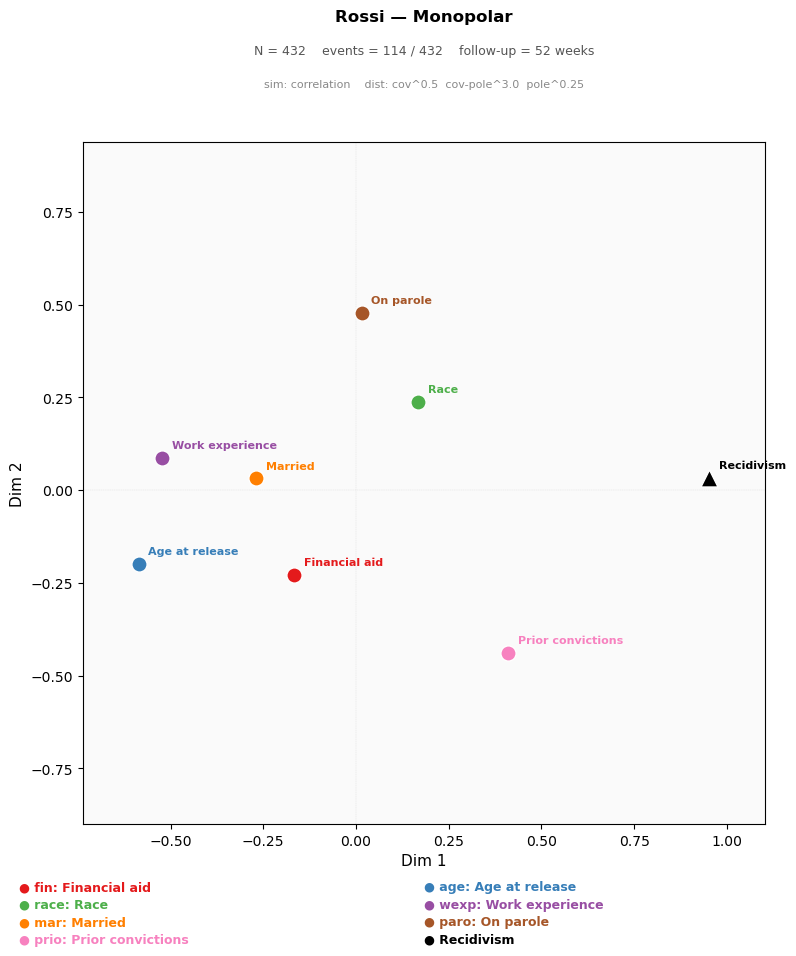

  Saved: p1_fig1_mono.png


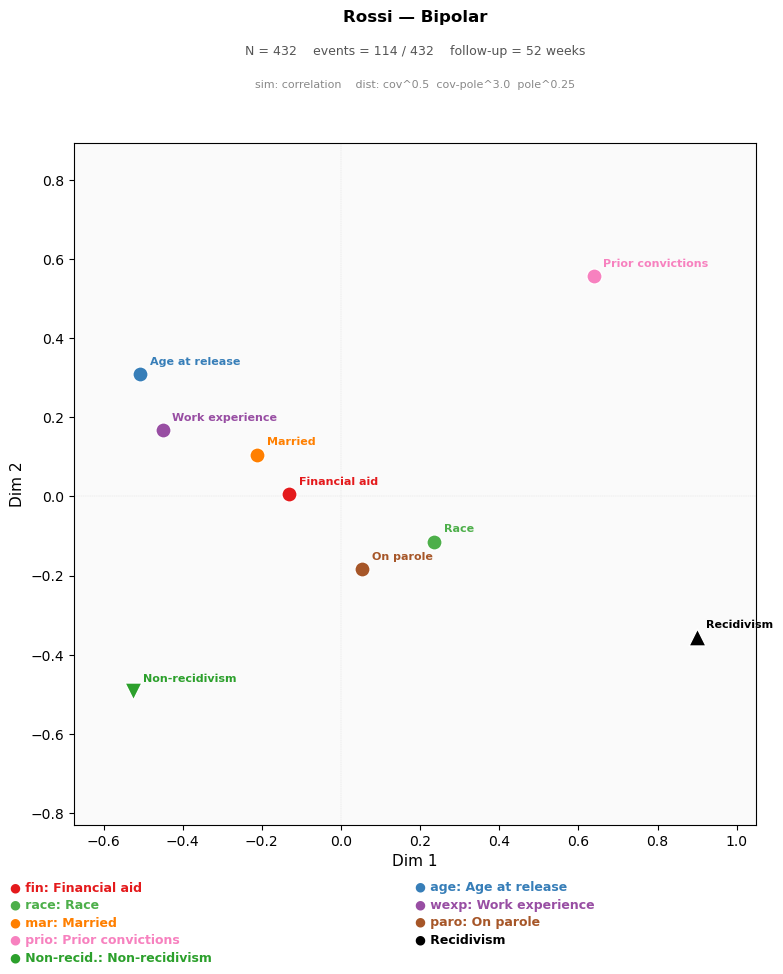

  Saved: p1_fig2_bi.png


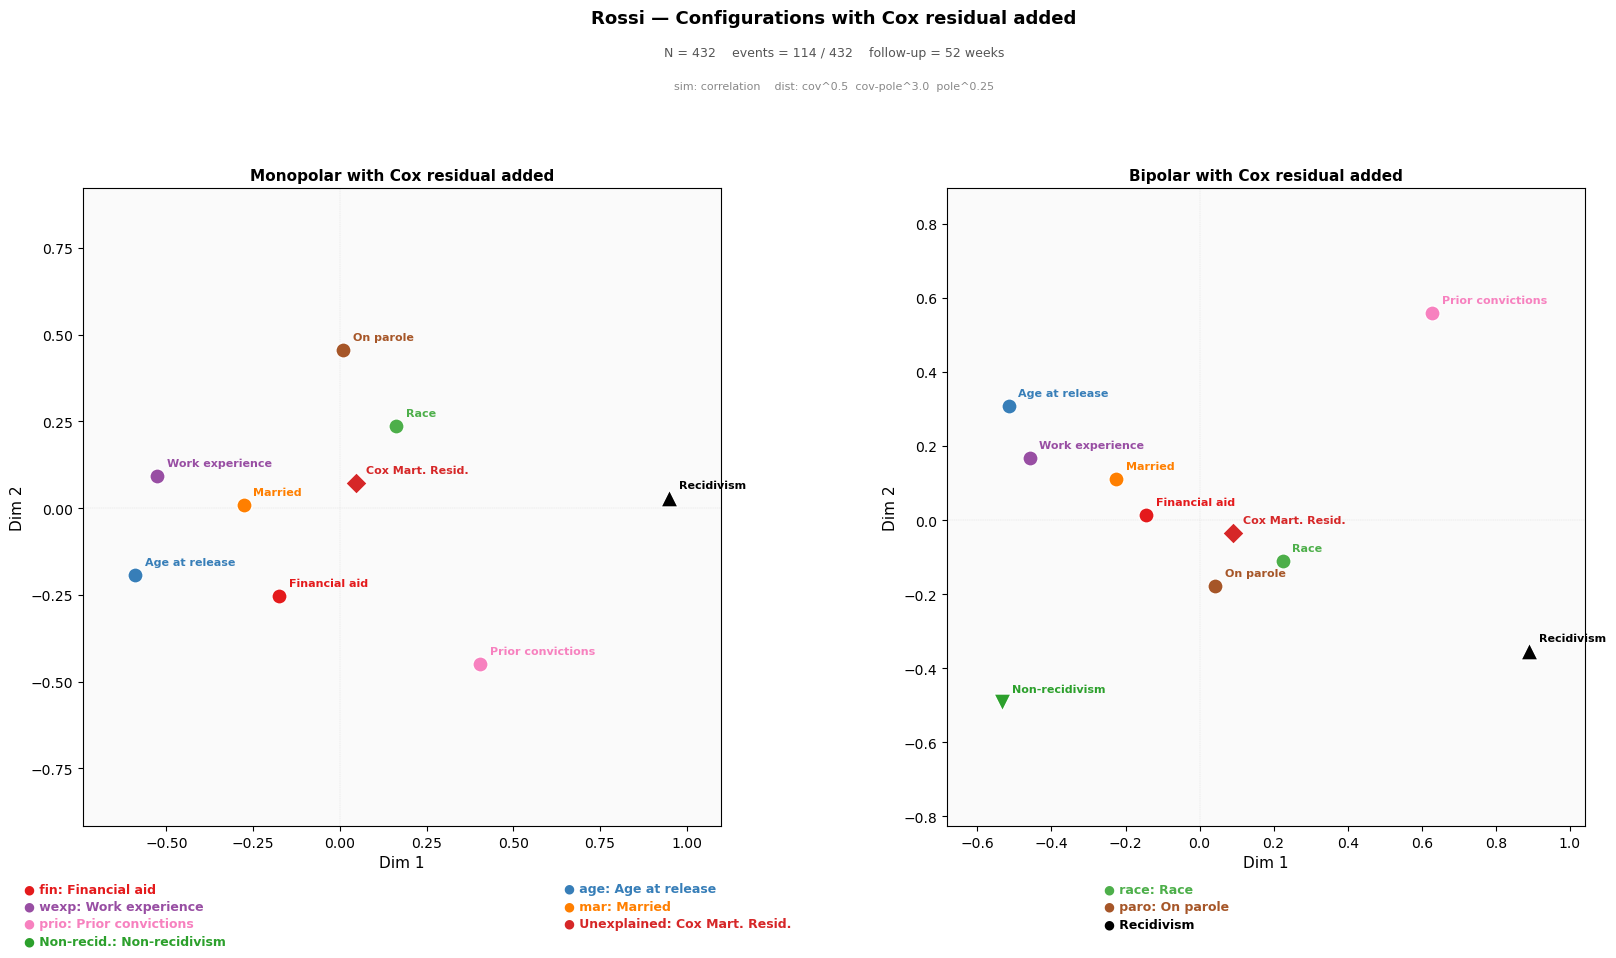

  Saved: p1_fig3_full.png

------------------------------------------------------------
  Supplementary diagnostics
------------------------------------------------------------



############################################################
##                                                        ##
##  WARNING about the diagnostic sections BELOW:          ##
##                                                        ##
##  Each configuration below shows TWO distinct distance  ##
##  matrices side by side. Do not confuse them.           ##
##                                                        ##
##  [A] Input distance matrix D                           ##
##      D_ab = (1 - r_ab) ^ alpha                         ##
##      Determined by the data; same across configs.      ##
##                                                        ##
##  [B] 2D CMDS coordinate distance D_hat                 ##
##      D_hat_ab = ||x_a - x_b|| in the 2D configuration. ##
##      Depends on the conf

In [14]:
# ============================================================
# 実行本体（2セル版）
# ============================================================
# このセルには、元 notebook の2セル目以降を順番どおりにまとめている。
# 計算ロジック・乱数 seed・出力処理は、可読性最大化版から変更しない。
# 「説明セル」は Python コメントとして残している。
# ============================================================


# ============================================================
# 元 notebook Cell 2
# ============================================================
# ------------------------------------------------------------
# 元 Markdown 説明セル（2セル版ではコメントとして保持）
# ------------------------------------------------------------
# # Paper 1 静的分析：Rossi データによる pole-augmented MDS
#
# この notebook は、論文 Paper 1 の静的分析を再現するためのドライバです。  
# 1セル目の `SurvivalPoleMDS` クラスは汎用処理を担当し、それ以降のセルで Rossi データ固有の設定、表、図、CSV 出力を管理します。
#
# 出力対応は次のとおりです。
#
# - Table 1: Monopolar configuration における recidivism pole までの距離
# - Table 2: Cox proportional hazards model
# - Figure 1: Monopolar configuration
# - Table 3: Bipolar configuration: 距離と Delta
# - Figure 2: Bipolar configuration
# - Table 4: Monopolar with Cox residual added: 距離
# - Table 5: Bipolar with Cox residual added: 距離と Delta
# - Figure 3: Monopolar (left) と Bipolar (right) with Cox residual
#
# Table 6 / Figure 4 のシミュレーション結果は、別 notebook で生成します。


# ============================================================
# 元 notebook Cell 3
# ============================================================
# ============================================================
# 2. 共通ヘルパー関数
# ============================================================
# このセルには、出力の見出し表示や表の丸めなど、
# 論文固有の計算ではない補助処理だけをまとめる。
# 本体の統計計算は SurvivalPoleMDS クラスに任せる。
# ============================================================

from tabulate import tabulate
from lifelines.datasets import load_rossi


def print_section(title, width=60, char='='):
    """Notebook の実行ログ用に、見出しを統一して表示する。"""
    print(f"\n{char * width}")
    print(f"  {title}")
    print(f"{char * width}")


def round_columns(df, columns, digits=3):
    """指定した数値列だけを丸めた DataFrame のコピーを返す。

    元の DataFrame を直接変更しないため、検算用の生値を残せる。
    df.attrs (距離の種類など) も明示的に引き継ぐ。
    """
    out = df.copy()
    for col in columns:
        out[col] = out[col].round(digits)
    # attrs を明示的に引き継ぐ (pandas の copy() は attrs を保持するが念のため).
    if hasattr(df, 'attrs'):
        out.attrs.update(df.attrs)
    return out


def print_table(title, df, floatfmt='.3f'):
    """論文表を notebook 上で見やすく表示する driver ラッパー.

    距離テーブルの場合は SurvivalPoleMDS.print_distance_table を呼び出して
    警告ブロック付きで表示する. それ以外 (Cox 表など) は単純な tabulate.

    クラス側 (SurvivalPoleMDS.print_distance_table) と同じ処理を, driver の
    自然な呼び出し名で使えるようにするためのラッパー.
    """
    if hasattr(df, 'attrs') and df.attrs.get('warning_text'):
        # 距離テーブル: 警告付き表示メソッドをクラスから呼ぶ.
        SurvivalPoleMDS.print_distance_table(df, title=title, floatfmt=floatfmt)
    else:
        # 警告不要のテーブル (Cox 表など): 従来どおりタイトル + tabulate.
        print_section(title)
        print(tabulate(df, headers='keys', tablefmt='simple',
                       floatfmt=floatfmt, showindex=False))


def save_table_csv(df, filename, header_comment=None):
    """表を CSV として保存し、保存先を標準出力に表示する driver ラッパー.

    距離テーブルの場合は SurvivalPoleMDS.save_distance_table_to_csv を呼び出し,
    CSV 冒頭に警告ブロックを埋め込む. それ以外は単純な to_csv.
    """
    if (hasattr(df, 'attrs') and df.attrs.get('warning_text')) or header_comment:
        SurvivalPoleMDS.save_distance_table_to_csv(df, filename, header_comment=header_comment)
    else:
        df.to_csv(filename, index=False)
    print(f"  Saved: {filename}")



# ============================================================
# 元 notebook Cell 4
# ============================================================
# ============================================================
# 3. Rossi データ固有の設定
# ============================================================
# ここに、データ、列名、表示名、距離変換指数、出力ファイル名を集約する。
# 設定値を1か所にまとめることで、あとで論文表記を変更したい場合でも
# どこを直せばよいか分かりやすくする。
# ============================================================

# --- 入力データ ---
# lifelines 付属の Rossi 再犯データ（Rossi, Berk, Lenihan 1980）
df = load_rossi()

# --- 生存時間データの列 ---
TIME_COL = 'week'
EVENT_COL = 'arrest'
TAU = 52

# --- 共変量 ---
# 論文 Method の illustrative data で使う 7 共変量。
COVARIATES = ['fin', 'age', 'race', 'wexp', 'mar', 'paro', 'prio']

# --- 極と Cox 残差の内部ラベル ---
EVENT_POLE = 'Recidivism'
NONEVENT_POLE = 'Non-recid.'
COX_RESID_NAME = 'Unexplained'
DATASET_NAME = 'Rossi'

# --- 論文中の表示名 ---
# 内部列名と論文表記を分けることで、計算コードと表示コードを混ぜない。
DISPLAY_NAMES = {
    'fin':           'Financial aid',
    'age':           'Age at release',
    'race':          'Race',
    'wexp':          'Work experience',
    'mar':           'Married',
    'paro':          'On parole',
    'prio':          'Prior convictions',
    EVENT_POLE:      'Recidivism',
    NONEVENT_POLE:   'Non-recidivism',
    COX_RESID_NAME:  'Cox Mart. Resid.',
}

# --- 距離変換指数 ---
# 論文 Method 3.3 の proposed transform。
# SurvivalPoleMDS の既定値と同じだが、論文再現用 notebook では明示しておく。
PROPOSED_EXPONENTS = {
    'cov_cov':   0.5,
    'cov_pole':  3.0,
    'pole_pole': 0.25,
}

# --- 出力ファイル名 ---
# 表番号とファイル名の対応をここで一元管理する。
OUTPUT_TABLES = {
    'table1_mono':       'p1_table1_mono.csv',
    'table2_cox':        'p1_table2_cox.csv',
    'table3_bipolar':    'p1_table3_bipolar.csv',
    'table4_monofull':   'p1_table4_monofull.csv',
    'table5_bipolarfull':'p1_table5_bipolarfull.csv',
}

FIGURE_PREFIX = 'p1'

# 補助診断は出力が長い。論文用の表・図だけ欲しい場合は False にする。
RUN_DIAGNOSTICS = True



# ============================================================
# 元 notebook Cell 5
# ============================================================
# ============================================================
# 4. SurvivalPoleMDS の初期化
# ============================================================
# 初期化時に、次の3つが計算される。
#   1. Null martingale residual     -> event pole
#   2. KM leave-one-out pseudo-value -> non-event pole
#   3. Cox martingale residual       -> additional covariate
# KM pseudo-value は N 回の Kaplan-Meier フィットを行うため、数秒かかる。
# ============================================================

print_section("Initializing SurvivalPoleMDS", char='-')

spm = SurvivalPoleMDS(
    df=df,
    covariates=COVARIATES,
    time_col=TIME_COL,
    event_col=EVENT_COL,
    tau=TAU,
    event_pole=EVENT_POLE,
    nonevent_pole=NONEVENT_POLE,
    cox_resid_name=COX_RESID_NAME,
    dataset_name=DATASET_NAME,
    display_names=DISPLAY_NAMES,
    **PROPOSED_EXPONENTS,
)

# 記述統計、残差の範囲、Cox 回帰の概略を表示する。
spm.print_descriptive()



# ============================================================
# 元 notebook Cell 6
# ============================================================
# ============================================================
# 5. 4種類の MDS 構成を計算
# ============================================================
# fit_all() は次の4構成を作る。
#   mono      : covariates + event pole
#   bi        : covariates + event pole + non-event pole
#   full_mono : covariates + Cox residual + event pole
#   full_bi   : covariates + Cox residual + event pole + non-event pole
# ============================================================

print_section("Fitting 4 configurations", char='-')
spm.fit_all()



# ============================================================
# 元 notebook Cell 7
# ============================================================
# ============================================================
# 6. 論文 Table 1-4 を作成
# ============================================================
# クラスは「どの表が Table 1 か」を知らない。
# 表番号はこのドライバセルで割り当てる。
#
# 注意:
#   - tab_mono_raw / tab_bi_raw / tab_monofull_raw / tab_bipolarfull_raw は検算用の生値。
#   - 表示・CSV用には丸めたコピーを使う。
# ============================================================

print_section("Building paper tables", char='-')

# Table 1: Monopolar configuration における event pole までの距離。
# Table 1: Monopolar configuration における event pole までの距離 (2D 座標距離)。
tab_mono_raw = spm.build_monopolar_cmds_distance_table('mono')
tab_mono = round_columns(tab_mono_raw, ['Distance to event pole'], digits=3)

# Table 2: Cox proportional hazards model。
# build_cox_table() は係数・ハザード比・p 値を論文表示向けの文字列に整形済み。
tab_cox = spm.build_cox_table()

# Table 3: Bipolar configuration の 2D 座標距離・Delta 表。
# Delta = (Distance to non-event pole) - (Distance to event pole)。
# 正なら event pole 側、負なら non-event pole 側。
tab_bi_raw = spm.build_bipolar_cmds_distance_table('bi')
tab_bi = round_columns(tab_bi_raw,
                       ['Distance to event pole', 'Distance to non-event pole', 'Delta'],
                       digits=3)

# Table 4: Cox residual を加えた monopolar 構成の距離表。
tab_monofull_raw = spm.build_monopolar_cmds_distance_table('full_mono')
tab_monofull = round_columns(tab_monofull_raw, ['Distance to event pole'], digits=3)

# Table 5: Cox residual を加えた bipolar 構成の距離・Delta 表。
tab_bipolarfull_raw = spm.build_bipolar_cmds_distance_table('full_bi')
tab_bipolarfull = round_columns(tab_bipolarfull_raw,
                                ['Distance to event pole', 'Distance to non-event pole', 'Delta'],
                                digits=3)

print("  Tables are ready: tab_mono, tab_cox, tab_bi, tab_monofull, tab_bipolarfull")



# ============================================================
# 元 notebook Cell 8
# ============================================================
# ============================================================
# 7. 論文 Table 1-5 を表示
# ============================================================

# Cox 表は距離テーブルではないので, 距離テーブル群と離して最初に出す.
# その方が距離テーブル群（Table 1, 3, 4, 5）が連続して並び,
# 警告ブロックも含めて視覚的に統一される.
# 表番号 (Table 1〜5) は論文上の番号のままで, ノートブックでの表示順だけ
# Cox を冒頭に持ってくる.
print_table(
    "Paper Table 2 — Cox proportional hazards model",
    tab_cox)

print_table(
    "Paper Table 1 — Distances to recidivism pole, monopolar configuration "
    "(2D CMDS coordinate distance)",
    tab_mono)
print_table(
    "Paper Table 3 — Bipolar configuration: distances and Delta "
    "(2D CMDS coordinate distance)",
    tab_bi)
print_table(
    "Paper Table 4 — Monopolar configuration with Cox residual added: distances "
    "(2D CMDS coordinate distance)",
    tab_monofull)
print_table(
    "Paper Table 5 — Bipolar configuration with Cox residual added: distances and Delta "
    "(2D CMDS coordinate distance)",
    tab_bipolarfull)



# ============================================================
# 元 notebook Cell 9
# ============================================================
# ============================================================
# 8. 論文 Table 1-5 を CSV 保存
# ============================================================
# CSV は、表示用に丸めた表を保存する。
# 生値が必要な場合は tab_mono_raw, tab_bi_raw, tab_monofull_raw, tab_bipolarfull_raw を使う。
# ============================================================

print_section("Exporting paper tables (CSV)", char='-')

save_table_csv(tab_mono, OUTPUT_TABLES['table1_mono'])
save_table_csv(tab_cox, OUTPUT_TABLES['table2_cox'])
save_table_csv(tab_bi, OUTPUT_TABLES['table3_bipolar'])
save_table_csv(tab_monofull, OUTPUT_TABLES['table4_monofull'])
save_table_csv(tab_bipolarfull, OUTPUT_TABLES['table5_bipolarfull'])



# ============================================================
# 元 notebook Cell 10
# ============================================================
# ============================================================
# 9. 論文 Figure 1-3 を PNG 保存
# ============================================================
# save_figures() は次の3つを保存する。
#   p1_fig1_mono.png : Figure 1
#   p1_fig2_bi.png   : Figure 2
#   p1_fig3_full.png : Figure 3
# ============================================================

print_section("Saving figures", char='-')
spm.save_figures(prefix=FIGURE_PREFIX)



# ============================================================
# 元 notebook Cell 11
# ============================================================
# ============================================================
# 10. 補助診断（相関・距離・座標）
# ============================================================
# 論文本文の表・図ではないが、検算用に相関行列、距離行列、座標を表示する。
# 出力が長いので、不要な場合は設定セルの RUN_DIAGNOSTICS を False にする。
# ============================================================

if RUN_DIAGNOSTICS:
    print_section("Supplementary diagnostics", char='-')
    spm.print_diagnostics()
else:
    print("Supplementary diagnostics skipped. Set RUN_DIAGNOSTICS = True to print them.")



# ============================================================
# 元 notebook Cell 12
# ============================================================
# ============================================================
# 11. 出力ファイル一覧
# ============================================================

print_section("Done. Generated outputs")

# 距離を含む表については, ファイル名と一緒に「これは 2D CMDS 座標距離」と
# 必ず明示する. 入力距離 D = (1-r)^alpha と混同しないため.
print("Tables (distance-bearing tables report 2D CMDS coordinate distances,")
print("not the input distance D = (1 - r)^alpha):")
print(f"  {OUTPUT_TABLES['table1_mono']:30s} "
      "(Table 1: Monopolar configuration; 2D CMDS coordinate distances to event pole)")
print(f"  {OUTPUT_TABLES['table2_cox']:30s} "
      "(Table 2: Cox proportional hazards model; not a distance table)")
print(f"  {OUTPUT_TABLES['table3_bipolar']:30s} "
      "(Table 3: Bipolar configuration; 2D CMDS coordinate distances and Delta)")
print(f"  {OUTPUT_TABLES['table4_monofull']:30s} "
      "(Table 4: Monopolar with Cox residual; 2D CMDS coordinate distances to event pole)")
print(f"  {OUTPUT_TABLES['table5_bipolarfull']:30s} "
      "(Table 5: Bipolar with Cox residual; 2D CMDS coordinate distances and Delta)")
print()
print("  Each distance-bearing CSV starts with a comment line (#) that")
print("  states the distance kind, so the file is self-describing.")

print("\nFigures:")
print(f"  {FIGURE_PREFIX}_fig1_mono.png              (Figure 1: Monopolar)")
print(f"  {FIGURE_PREFIX}_fig2_bi.png                (Figure 2: Bipolar)")
print(f"  {FIGURE_PREFIX}_fig3_full.png              (Figure 3: Monopolar/Bipolar with Cox residual)")

print("\nNote:")
print("  Table 6 and Figure 4 are generated by the simulation notebook.")

